In [1]:
import numpy as np

def gradient_descent(start_x=5.0,learning_rate=0.1,interations=10):
  x = start_x
  for i in range(interations):
    grad = 2 * x # derivative of X^2
    x = x - learning_rate * grad
    print(f"Iteration {i+1}: X = {x:.4f}, Gradient = {grad:.4f}")
  return x

In [2]:
optimized_x = gradient_descent()
print('final optimized x ',optimized_x)

Iteration 1: X = 4.0000, Gradient = 10.0000
Iteration 2: X = 3.2000, Gradient = 8.0000
Iteration 3: X = 2.5600, Gradient = 6.4000
Iteration 4: X = 2.0480, Gradient = 5.1200
Iteration 5: X = 1.6384, Gradient = 4.0960
Iteration 6: X = 1.3107, Gradient = 3.2768
Iteration 7: X = 1.0486, Gradient = 2.6214
Iteration 8: X = 0.8389, Gradient = 2.0972
Iteration 9: X = 0.6711, Gradient = 1.6777
Iteration 10: X = 0.5369, Gradient = 1.3422
final optimized x  0.5368709120000001


In [3]:
# using tensorFlow
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# data
X = np.array([1,2,3,4,5] , dtype=np.float32).reshape(-1,1)
y = np.array([5,7,9,11,13] , dtype=np.float32)

In [5]:
# create a model (1 layer , 1 neuron)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[1]) # y = w * x+b
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# model with cost function
model.compile(
    optimizer='adam', # optimizer
    loss='mean_squared_error', # MSE - Cost function
    metrics = ['mae'] # only view
)

In [7]:
# train the model
print("traning model")
history = model.fit(X,y,epochs=300,verbose=0) # epochs loop steps 300

traning model


In [8]:
# final weight and cost
w , b = model.get_weights()
print(f"Model - learning y = {w[0][0]:.2f} * X + {b[0]:.2f}")
print(f"FInal Cost Loss =  {history.history['loss'][-1]:.4f}\n")

Model - learning y = 0.57 * X + 0.29
FInal Cost Loss =  53.0724



In [9]:
# predictions test
for x_val in [6,7,10]:
  pred = model.predict(np.array([x_val]),verbose=0)[0][0]
  print(f"Prediction for {x_val} is {pred:.2f}")

Prediction for 6 is 3.72
Prediction for 7 is 4.29
Prediction for 10 is 6.01


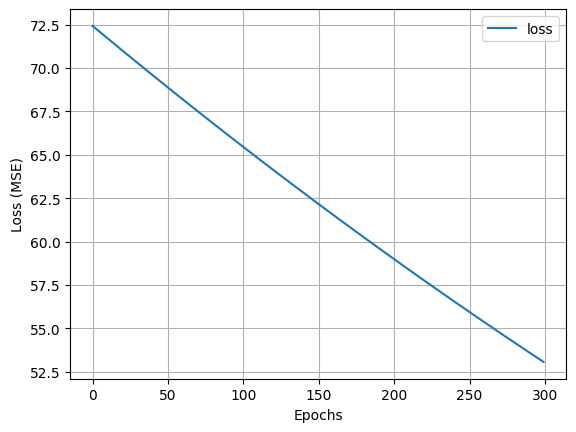

In [10]:
# check loss
plt.plot(history.history['loss'],label='loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# cost function - mean_squared_error - misteks measure
# optimizer = cost low -> adam
# traning - hue , weight , low -> model.fit()